In [ ]:
# Cell 1: Setup
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tambahkan path folder root ke sys.path agar Python bisa menemukan estimator.py
sys.path.append('C:/StatProb/final_project')

# Cek apakah file estimator.py ditemukan
if os.path.exists('C:/StatProb/final_project/estimator.py'):
    print("✓ estimator.py ditemukan")
else:
    print("✗ estimator.py TIDAK ditemukan, periksa path")



✓ estimator.py ditemukan
✓ Semua fungsi berhasil diimport


In [10]:
# Cell 2: Import fungsi dari estimator.py
from estimator import (
    mle_bernoulli,
    log_likelihood_bernoulli,
    mle_poisson,
    log_likelihood_poisson,
    beta_posterior
)

print("✓ Semua fungsi berhasil diimport")

✓ Semua fungsi berhasil diimport


In [19]:
# Cell 3: Baca data dari file pr_clean.csv (satu file dengan kolom status)

import pandas as pd

# Ubah Cell 3 menjadi seperti ini:
path_file = 'C:/StatProb/final_project/data/clean/pr_clean.csv'

df_pr = pd.read_csv(path_file)

# Tampilkan informasi awal untuk verifikasi
print(f"Total data PR: {len(df_pr)}")

# Tampilkan informasi awal untuk verifikasi
print(f"Total data PR: {len(df_pr)}")
print(f"Kolom yang tersedia: {df_pr.columns.tolist()}")
print("\n5 baris pertama:")
print(df_pr.head())

# Cek nilai unik pada kolom status
print(f"\nNilai unik pada kolom 'status': {df_pr['status'].unique()}")




Total data PR: 789
Total data PR: 789
Kolom yang tersedia: ['number', 'title', 'status', 'created_at', 'closed_at', 'comments', 'user']

5 baris pertama:
   number                                              title  status  \
0   65697  Revert "BUG: reject unhashable elements in Ind...  merged   
1   65693  [backport 3.0.x] TST: Adjust xfails for fastpa...  merged   
2   65686  BUG: Fix Index.where raising AssertionError wh...  merged   
3   65681              ASV: garbage collect as part of setup  merged   
4   65680    Bump github/codeql-action from 4.35.4 to 4.35.5  merged   

                  created_at                  closed_at  comments  \
0  2026-05-20 16:38:19+00:00  2026-05-20 21:22:12+00:00         1   
1  2026-05-20 14:03:23+00:00  2026-05-20 16:33:10+00:00         0   
2  2026-05-19 18:54:58+00:00  2026-05-21 14:34:32+00:00         7   
3  2026-05-18 21:24:09+00:00  2026-05-23 17:26:56+00:00         1   
4  2026-05-18 13:54:43+00:00  2026-05-18 15:27:45+00:00         0   

In [18]:
# Cell 4: Hitung statistik
k = len(df_pr[df_pr['status'] == 'merged'])
n = len(df_pr)

print("=" * 50)
print("HASIL ESTIMASI MLE BERNOULLI")
print("=" * 50)
print(f"Total PR (n)        : {n}")
print(f"PR merged (k)       : {k}")
print(f"PR unmerged         : {n - k}")
print(f"θ̂ = k/n             : {k/n:.4f} ({k/n*100:.2f}%)")
print("=" * 50)


HASIL ESTIMASI MLE BERNOULLI
Total PR (n)        : 789
PR merged (k)       : 500
PR unmerged         : 289
θ̂ = k/n             : 0.6337 (63.37%)


In [20]:
# Cell 5: Hitung log-likelihood pada nilai MLE
log_lik = log_likelihood_bernoulli(theta_hat, k, n)
print(f"Log_likelihood pada θ̂ = {log_lik:.4f}")

Log_likelihood pada θ̂ = -518.3333


In [21]:
# Cell 6: Hitung posterior Beta
posterior = beta_posterior(k, n)

print("\n" + "=" * 50)
print("HASIL POSTERIOR BETA")
print(f"Prior: Beta(1, 1)")
print(f"Posterior: Beta(α={posterior['alpha']:.2f}, β={posterior['beta']:.2f})")
print(f"Mode posterior  = {posterior['mode']:.4f}")
print(f"Mean posterior  = {posterior['mean']:.4f}")
print("=" * 50)


HASIL POSTERIOR BETA
Prior: Beta(1, 1)
Posterior: Beta(α=501.00, β=290.00)
Mode posterior  = 0.6337
Mean posterior  = 0.6334


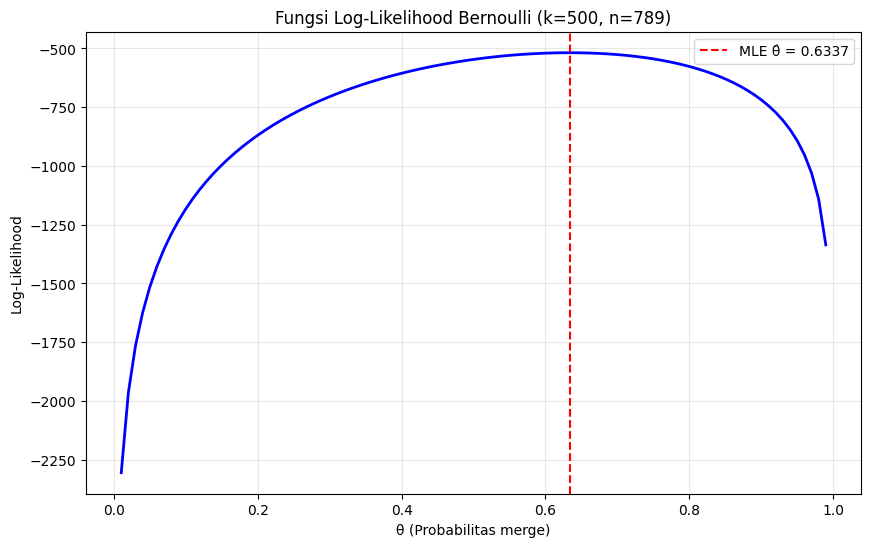

In [22]:
# Cell 7: Plot log-likelihood
theta_range = np.linspace(0.01, 0.99, 100)
likelihood_values = [log_likelihood_bernoulli(t, k, n) for t in theta_range]

plt.figure(figsize=(10, 6))
plt.plot(theta_range, likelihood_values, 'b-', linewidth=2)
plt.axvline(x=theta_hat, color='r', linestyle='--', label=f'MLE θ̂ = {theta_hat:.4f}')
plt.xlabel('θ (Probabilitas merge)')
plt.ylabel('Log-Likelihood')
plt.title(f'Fungsi Log-Likelihood Bernoulli (k={k}, n={n})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

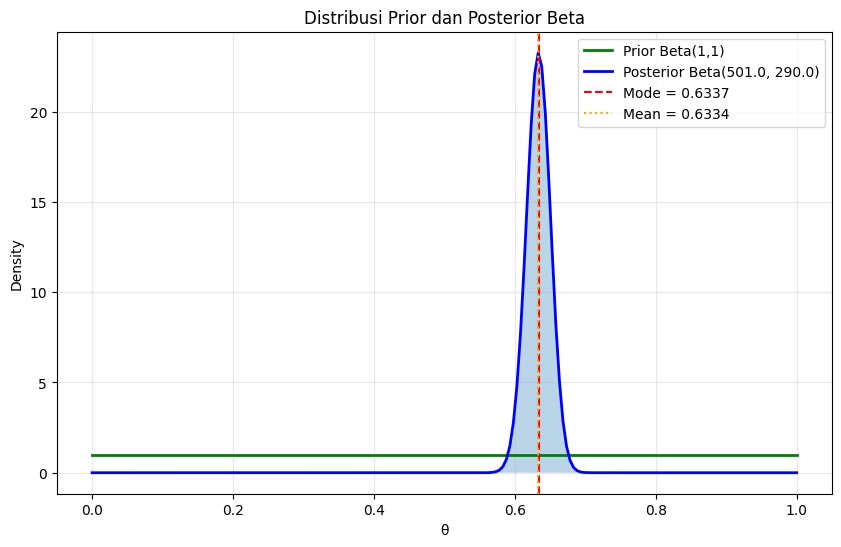

In [23]:
# Cell 8: Plot posterior Beta
from scipy.stats import beta

x = np.linspace(0, 1, 200)
prior_dist = beta.pdf(x, 1, 1)
posterior_dist = beta.pdf(x, posterior['alpha'], posterior['beta'])

plt.figure(figsize=(10, 6))
plt.plot(x, prior_dist, 'g-', label='Prior Beta(1,1)', linewidth=2)
plt.plot(x, posterior_dist, 'b-', label=f"Posterior Beta({posterior['alpha']:.1f}, {posterior['beta']:.1f})", linewidth=2)
plt.axvline(x=posterior['mode'], color='r', linestyle='--', label=f"Mode = {posterior['mode']:.4f}")
plt.axvline(x=posterior['mean'], color='orange', linestyle=':', label=f"Mean = {posterior['mean']:.4f}")
plt.fill_between(x, 0, posterior_dist, alpha=0.3)
plt.xlabel('θ')
plt.ylabel('Density')
plt.title('Distribusi Prior dan Posterior Beta')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()